<font size="+3">AF3 benchmark on TCR:epitope interactions</font> 

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import roc_curve, roc_auc_score

import math
from functools import reduce

# AF3 input

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_81051/2126991102.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_81051/2126991102.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_neg_sub = (df_neg.groupby(

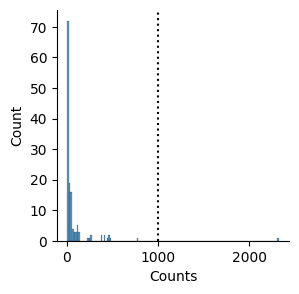

In [25]:
topdir = 'Supplementary_Tables'


df = pd.read_csv(f'{topdir}/Supplementary_Table_1.csv')
df = df.drop(columns=['data_usage', 'CV_id'])
df = df.drop_duplicates()

df_pos = df[(df['dataset_source'] == 'Public Paired Data') & (df['Label'] == 1)]
df_neg = df[(df['dataset_source'] == 'Public TCRs with undetermined specificities') & (df['Label'] == 0)]

counts = df_pos['Epitope'].value_counts().reset_index()
counts.columns = ['Epitope', 'Counts']

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.histplot(data=counts, x='Counts', ax=ax)
ax.axvline(1000, color='black', linestyle=':')
sns.despine()

# subsample positives n > 1000
df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
df_pos_sub.to_csv('positives.csv', index=False)

# how many positives per epitope after subsampling
pos_counts = df_pos_sub['Epitope'].value_counts()

# sample matching number of negatives per epitope
df_neg_sub = (df_neg.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), pos_counts.get(x.name, 0)), random_state=42)).reset_index(drop=True))
df_neg_sub.to_csv('negatives.csv', index=False)

In [28]:
batches = ['positives', 'negatives']
exclude_mhc = ['DRB10101', 'DRB10701', 'DRB11501', 'na']

for batch in batches:
    os.makedirs(batch, exist_ok=True)
    df = pd.read_csv(f'{batch}.csv')
    df = df.drop(columns=['Label', 'dataset_source'])
    df['peptide'] = df['Epitope'].str.split('_').str[1]
    df['MHC'] = df['Epitope'].str.split('_').str[0]
    

    # exclude unclear mhcs
    df = df[~df['MHC'].isin(exclude_mhc)]

    # split alpha/beta if present
    mhc_split = df['MHC'].str.split('-', n=1, expand=True)

    # first allele always exists
    df['MHC_allele_a'] = 'HLA_' + mhc_split[0]

    # second allele only exists for entries with '-'
    df['MHC_allele_b'] = mhc_split[1]
    df['MHC_allele_b'] = 'HLA_' + df['MHC_allele_b'].fillna('NA')
    df.loc[mhc_split[1].isna(), 'MHC_allele_b'] = 'NA'
    df = df.drop(columns=['Epitope', 'MHC'])

    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
    df.insert(0, 'id', tcr_ids)

    # for now only class I
    df = df[df['MHC_allele_b'] == 'NA']
    df = df.drop(columns=['MHC_allele_b'])
    print(np.unique(df['MHC_allele_a']))
    df.to_csv(f'{batch}/AF3_class_I.csv', index=False)
    print(len(df))

['HLA_A0101' 'HLA_A0201' 'HLA_A0301' 'HLA_A1101' 'HLA_A2402' 'HLA_A3002'
 'HLA_A6801' 'HLA_B0702' 'HLA_B0801' 'HLA_B1501' 'HLA_B3501' 'HLA_B3701'
 'HLA_B4001' 'HLA_B4402' 'HLA_B5101' 'HLA_B5701' 'HLA_E0103']
9375
['HLA_A0101' 'HLA_A0201' 'HLA_A0301' 'HLA_A1101' 'HLA_A2402' 'HLA_A3002'
 'HLA_A6801' 'HLA_B0702' 'HLA_B0801' 'HLA_B1501' 'HLA_B3501' 'HLA_B3701'
 'HLA_B4001' 'HLA_B4402' 'HLA_B5101' 'HLA_B5701' 'HLA_E0103']
9375


# Analyze AF3 output

In [7]:
batches = ['positives', 'negatives']

lst = []
for batch in batches:
    df_input = pd.read_csv(f'{batch}/AF3_class_I_input.txt', sep='\t')[['id', 'peptide']]
    df_output = pd.read_csv(f'{batch}/AF3_class_I_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
    
    df = pd.merge(df_input, df_output, on='id')
    df['batch'] = batch
    lst.append(df)

df = pd.concat(lst)
df.to_csv('AF3_class_I_output.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_5182/219419133.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize='small')
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_5182/219419133.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize='small')
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_5182/219419133.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize='small')
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_5182/219419133.py:47: UserWarning: No artists with la

,peptide,n_samples,n_samples_iptm_0.5,n_samples_iptm_0.8,auc
0,AIMEKNIVL,10,5,3,0.750000
1,ALAGIGILTV,65,61,25,0.857396
2,ALGIGILTV,21,17,5,0.848073
3,ALSKGVHFV,26,11,5,0.720414
4,ALWEIQQVV,28,9,0,0.490434


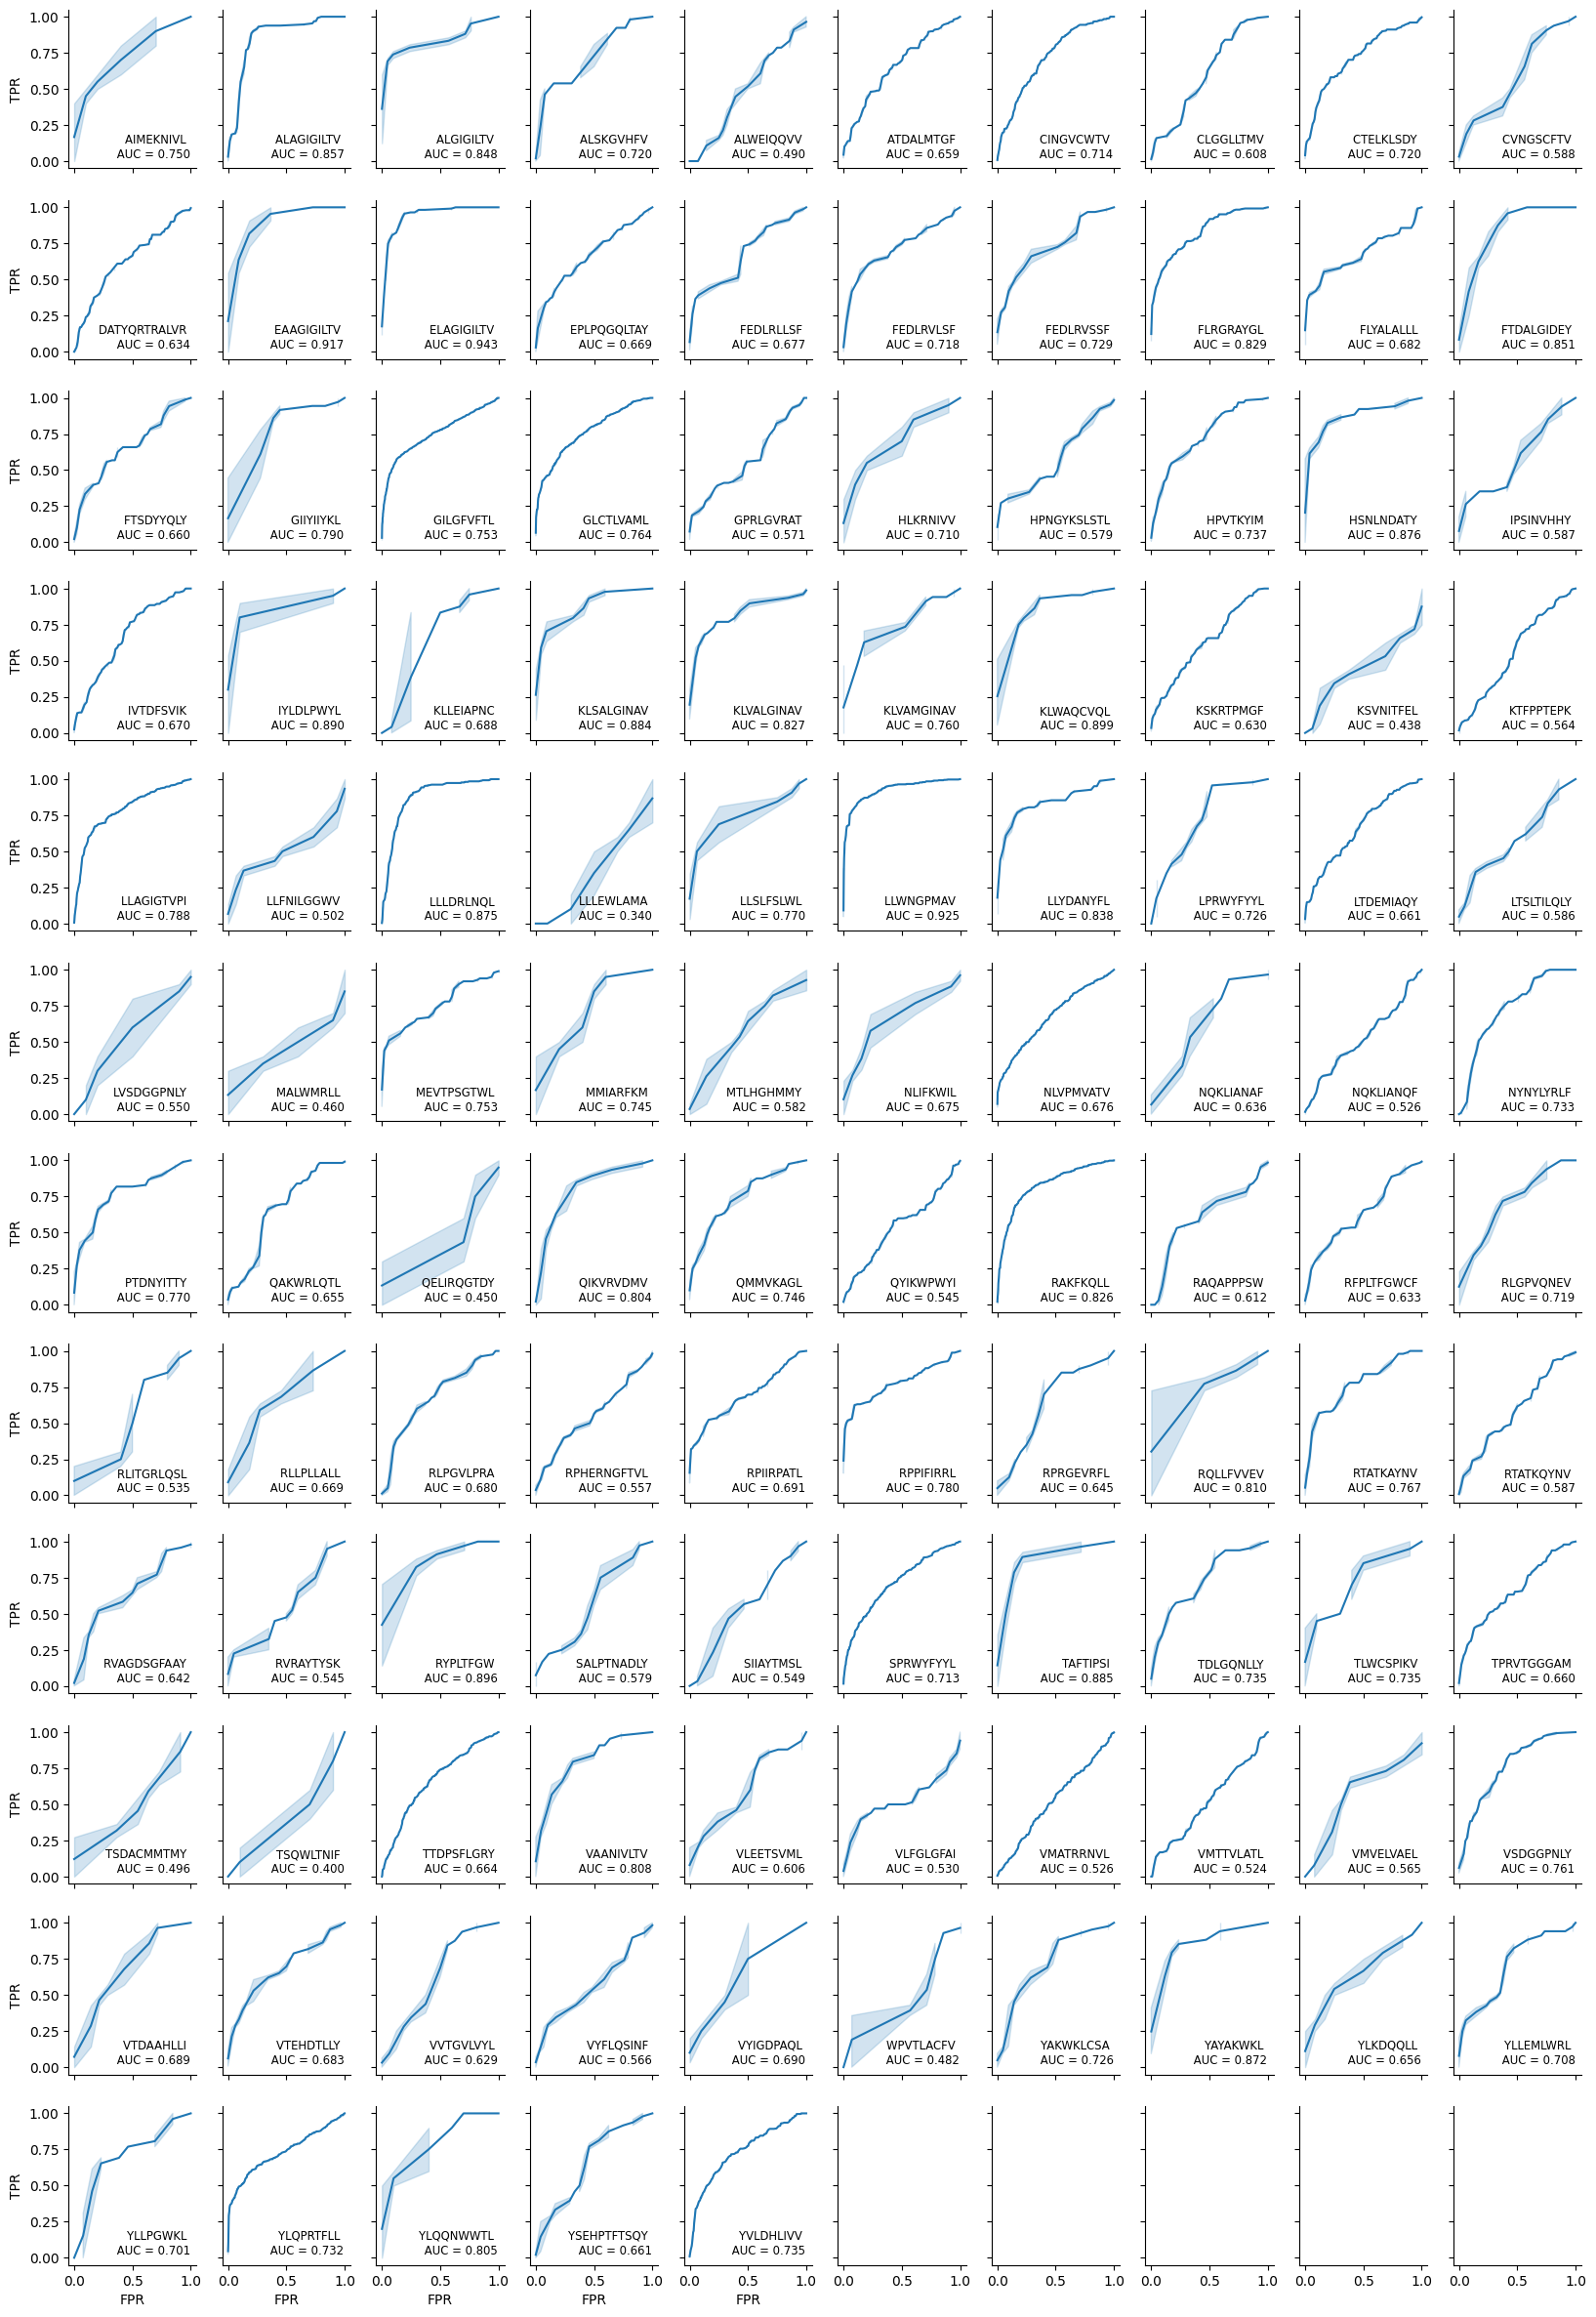

In [37]:
df = pd.read_csv('AF3_class_I_output.csv')

fig, axes = plt.subplots(12,10, figsize=(20,30), sharex=True, sharey=True )

dico = {
    'peptide' : [],
    'n_samples' : [],
    'n_samples_iptm_0.5' : [],
    'n_samples_iptm_0.8' : [],
    'auc' : [],
}

for cnt, (name, group) in enumerate(df.groupby('peptide')):

    row = cnt // 10
    col = cnt % 10
    
    ax = axes[row, col]

    scores_pos = group.loc[df['batch'] == 'positives', "AF3_iptm_pair_mean"].values
    scores_neg = group.loc[df['batch'] == 'negatives', "AF3_iptm_pair_mean"].values

    # create labels
    y_true = np.concatenate([
        np.ones(len(scores_pos)),      # positives = 1
        np.zeros(len(scores_neg))      # negatives = 0
    ])

    # combine scores
    y_scores = np.concatenate([scores_pos, scores_neg])

    # compute ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)

    sns.lineplot(x=fpr, y=tpr, ax=ax)
    
    ax.text(
        0.95, 0.05,                      # (x, y) in axis coordinates
        f"{name} \n AUC = {auc:.3f}",
        transform=ax.transAxes,
        ha='right',                      # align right
        va='bottom',                     # align bottom
        fontsize='small'
    )

    ax.legend(frameon=False, fontsize='small')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    sns.despine()

    dico['peptide'].append(name)
    dico['n_samples'].append(len(scores_pos))
    dico['n_samples_iptm_0.5'].append((scores_pos > 0.5).sum())
    dico['n_samples_iptm_0.8'].append((scores_pos > 0.8).sum())
    dico['auc'].append(auc)

df = pd.DataFrame(dico)
df.to_csv('AF3_class_I_auc.csv', index=False)
df.head()

10
10


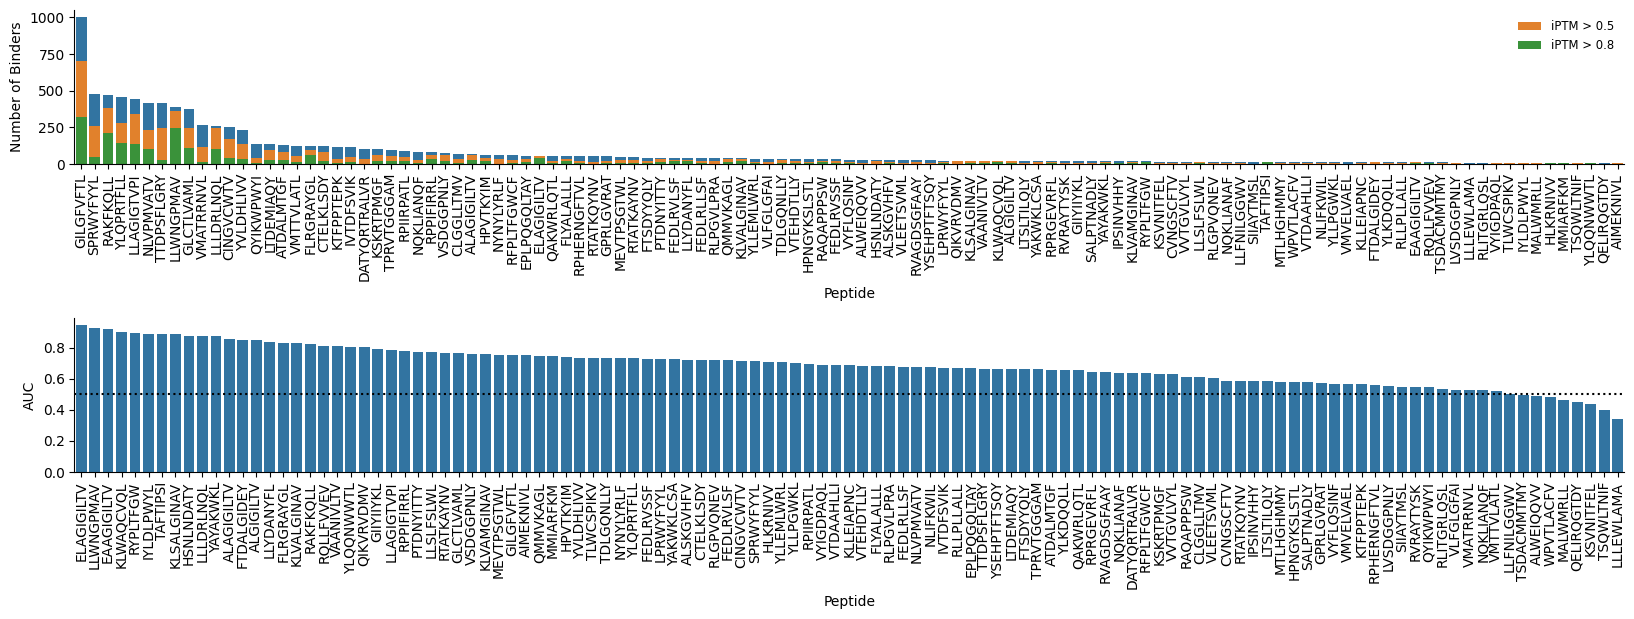

In [40]:
df = pd.read_csv('AF3_class_I_auc.csv')

fig, axes = plt.subplots(2, 1, figsize=(20,6))
fig.subplots_adjust(hspace=1)

df = df.sort_values(by='n_samples', ascending=False)
sns.barplot(df, x='peptide', y='n_samples', ax=axes[0])
sns.barplot(df, x='peptide', y='n_samples_iptm_0.5', ax=axes[0], label = 'iPTM > 0.5')
sns.barplot(df, x='peptide', y='n_samples_iptm_0.8', ax=axes[0], label = 'iPTM > 0.8')
axes[0].tick_params(axis='x', rotation=90)
print(np.min(df['n_samples']))
axes[0].set_xlabel('Peptide')
axes[0].set_ylabel('Number of Binders')
axes[0].legend(frameon=False, fontsize='small')

df = df.sort_values(by='auc', ascending=False)
sns.barplot(df, x='peptide', y='auc', ax=axes[1])
axes[1].tick_params(axis='x', rotation=90)
print(np.min(df['n_samples']))
axes[1].set_xlabel('Peptide')
axes[1].set_ylabel('AUC')
axes[1].axhline(0.5, color='black', linestyle=':')

sns.despine()

# TCR motifs

In [64]:
df = pd.read_csv('AF3_class_I_auc.csv')
print(df)


target = 1000
df['factor'] = target // df['n_samples']
df = df.rename(columns={'peptide':'model'})
df.to_csv('AF3_class_I_factor.csv', index=False)
df.head()

         peptide  n_samples  n_samples_iptm_0.5  n_samples_iptm_0.8       auc
0      AIMEKNIVL         10                   5                   3  0.750000
1     ALAGIGILTV         65                  61                  25  0.857396
2      ALGIGILTV         21                  17                   5  0.848073
3      ALSKGVHFV         26                  11                   5  0.720414
4      ALWEIQQVV         28                   9                   0  0.490434
..           ...        ...                 ...                 ...       ...
110     YLLPGWKL         13                   8                   0  0.701183
111    YLQPRTFLL        457                 279                 140  0.731833
112    YLQQNWWTL         10                   7                   5  0.805000
113  YSEHPTFTSQY         24                   8                   1  0.661458
114    YVLDHLIVV        233                 138                  32  0.735490

[115 rows x 5 columns]


,model,n_samples,n_samples_iptm_0.5,n_samples_iptm_0.8,auc,factor
0,AIMEKNIVL,10,5,3,0.750000,100
1,ALAGIGILTV,65,61,25,0.857396,15
2,ALGIGILTV,21,17,5,0.848073,47
3,ALSKGVHFV,26,11,5,0.720414,38
4,ALWEIQQVV,28,9,0,0.490434,35


In [51]:
df = pd.read_csv('AF3_class_I_output.csv')
df = df[df['batch'] == 'positives']
anno = pd.read_csv('positives/AF3_class_I_input.txt', sep='\t')[['id', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB']]

df = pd.merge(df, anno, on='id')
df = df.drop(columns=['batch'])
df = df.rename(columns={'peptide':'model'})
df.to_csv('AF3_class_I_motif.csv', index=False)
df.head()

df = df[df['model'].isin(['ELAGIGILTV', 'LLWNGPMAV', 'GILGFVFTL'])]
df.to_csv('test.csv', index=False)